# 🚗 Vehicle Data Augmenter & Balancer
Este notebook proporciona un entorno interactivo para analizar, balancear y aumentar conjuntos de datos de imágenes, especialmente diseñado para el `Vehicle_MEX_Dataset`.

### Tareas que realiza:
1. Selección interactiva del dataset mediante interfaz UI.
2. Análisis de desbalanceo de clases y conteo automático.
3. Previsualización de sugerencias de Aumento de Datos (Albumentations).
4. Redimensionado estandarizado a 640x640 (con padding para evitar deformaciones, usando interpolación Lanczos).
5. Procesamiento estructurado y balanceo de clases minoritarias.
6. Validación post-procesamiento.

## 0. Instalación de Requisitos y Configuración del Entorno
Ejecuta esta celda para asegurarte de tener todas las librerías necesarias instaladas en el entorno local.

In [27]:
# !pip install opencv-python albumentations ipywidgets matplotlib numpy tqdm pillow

### Importar Librerías

In [28]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import ipywidgets as widgets
from IPython.display import display, clear_output
from tqdm.notebook import tqdm
import shutil
import random

## 1. Selección de Directorio (Interactivo)
Selecciona la carpeta que contiene las subcarpetas de las clases (por ejemplo, la carpeta `train`).

In [ ]:
# Crear inputs de texto interactivos para las rutas de los directorios
folder_input = widgets.Text(
    value=r'D:\Vehicle_MEX_Dataset\Vehicle_classification.v1\train', # Cambia esta ruta a tu directorio de entrenamiento
    description='Directorio Origen:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)
output_input = widgets.Text(
    value=r'D:\Vehicle_MEX_Dataset\Vehicle_classification.v1\train_augmented', # Cambia esta ruta a tu directorio de salida
    description='Directorio Salida:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

display(folder_input)
display(output_input)

Text(value='D:\\Vehicle_MEX_Dataset\\Vehicle_classification.v1\\train', description='Directorio Origen:', layo…

Text(value='D:\\Vehicle_MEX_Dataset\\Vehicle_classification.v1\\train_augmented', description='Directorio Sali…

## 2. Pre-validación y Análisis Automático del Dataset
Escaneamos la carpeta origen, verificamos la integridad de las imágenes y mostramos una gráfica con el nivel de desbalanceo.

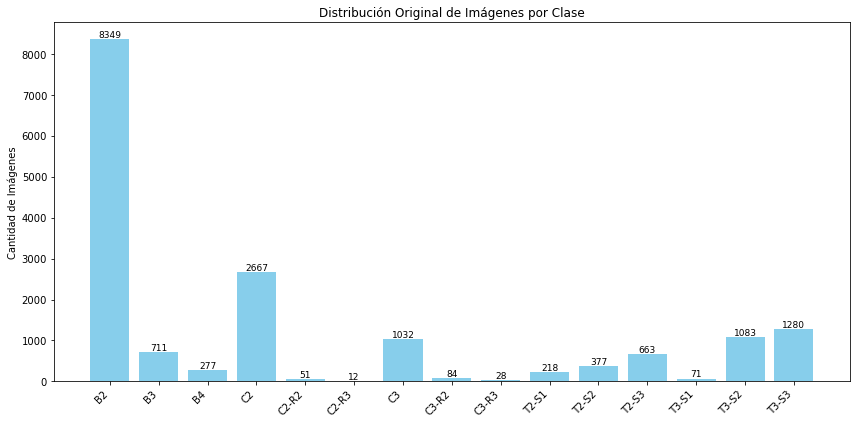

📊 Análisis Completo:
- Total de clases detectadas: 15
- Clase mayoritaria: B2 (8349 imágenes)
- Clase minoritaria: C2-R3 (12 imágenes)

💡 Sugerencia: El script equilibrará todas las clases para que tengan 8349 imágenes.


In [30]:
def analyze_dataset(data_dir):
    if not os.path.exists(data_dir):
        print(f"Error: El directorio {data_dir} no existe. Verifica la ruta ingresada.")
        return None, None
        
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_counts = {}
    
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        images = glob.glob(os.path.join(cls_path, '*.*'))
        # Filtrar para considerar únicamente archivos de imagen válidos
        valid_images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
        class_counts[cls] = len(valid_images)
        
    # Visualización
    plt.figure(figsize=(12, 6))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.title('Distribución Original de Imágenes por Clase')
    plt.ylabel('Cantidad de Imágenes')
    
    # Agregar etiquetas de valor numérico sobre cada barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=9)
        
    plt.tight_layout()
    plt.show()
    
    target_count = max(class_counts.values())
    print(f"📊 Análisis Completo:")
    print(f"- Total de clases detectadas: {len(classes)}")
    print(f"- Clase mayoritaria: {max(class_counts, key=class_counts.get)} ({target_count} imágenes)")
    print(f"- Clase minoritaria: {min(class_counts, key=class_counts.get)} ({min(class_counts.values())} imágenes)")
    print(f"\n💡 Sugerencia: El script equilibrará todas las clases para que tengan {target_count} imágenes.")
    
    return class_counts, target_count

# Ejecutar el análisis usando el valor del widget
class_counts, target_count = analyze_dataset(folder_input.value)

## 3. Configuración de Augmentations y Redimensionamiento
Definimos la lógica central:
- **`resize_and_pad`**: Mantiene el aspecto original y añade relleno simétrico negro para llegar a 640x640 sin distorsionar los vehículos.
- **`aug_pipeline`**: Aplica variaciones realistas (iluminación, ruido, perspectiva leve, volteo) usando Albumentations, sin destruir la semántica.

In [31]:
def resize_and_pad(image, target_size=640):
    '''Redimensiona manteniendo el aspect ratio y aplica padding usando interpolación Lanczos de alta calidad.'''
    h, w = image.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    
    # Resize con Lanczos
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    
    # Calcular padding para obtener un cuadrado perfecto de 640x640
    top = (target_size - new_h) // 2
    bottom = target_size - new_h - top
    left = (target_size - new_w) // 2
    right = target_size - new_w - left
    
    # Relleno con pixeles negros
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded

# Pipeline sugerido de Albumentations adaptado para vehículos
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5), # Volteo horizontal (válido para vehículos, simula tráfico en otro sentido)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6), # Cambios de luz
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3), # Simular ruido de cámara de seguridad
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0), # Cambios leves de perspectiva/inclinación
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2) # Distorsión elástica leve para generalizar chasis
])

<ipython-input-31-cedb9215eb84>:26: UserWarning: Argument 'alpha_affine' is not valid and will be ignored.
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2) # Distorsión elástica leve para generalizar chasis


### Módulo de Previsualización
Antes de procesar todo el conjunto, revisemos cómo se verán los aumentos en una imagen de prueba. Esto te permite validar o descartar técnicas.

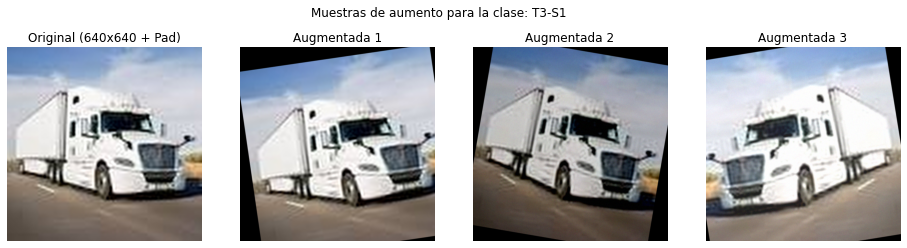

In [32]:
def preview_augmentations(data_dir, class_counts):
    if not class_counts: return
    # Tomar una imagen de muestra de una clase aleatoria
    sample_cls = random.choice(list(class_counts.keys()))
    images_path = glob.glob(os.path.join(data_dir, sample_cls, '*.*'))
    
    if not images_path:
        print("No hay imágenes en la clase seleccionada.")
        return
        
    sample_img_path = random.choice(images_path)
    
    # Cargar y convertir BGR (OpenCV) a RGB (Matplotlib)
    image = cv2.imread(sample_img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Procesar
    padded_image = resize_and_pad(image)
    
    # Mostrar resultados
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(padded_image)
    axes[0].set_title("Original (640x640 + Pad)")
    axes[0].axis('off')
    
    for i in range(1, 4):
        augmented = aug_pipeline(image=padded_image)['image']
        axes[i].imshow(augmented)
        axes[i].set_title(f"Augmentada {i}")
        axes[i].axis('off')
        
    plt.suptitle(f"Muestras de aumento para la clase: {sample_cls}")
    plt.show()

# Ejecutar previsualización
preview_augmentations(folder_input.value, class_counts)

## 4. Procesamiento Central y Generación
Convertiremos todas las imágenes a 640x640 y generaremos nuevas variaciones para las clases desbalanceadas, guardando el resultado en la carpeta de salida manteniendo la misma estructura.

In [33]:
def process_and_balance_dataset(input_dir, output_dir, class_counts, target_count):
    if os.path.exists(output_dir):
        print(f"⚠️ El directorio de salida '{output_dir}' ya existe. Limpiando para evitar duplicados...")
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)
    
    print(f"🚀 Iniciando procesamiento. Igualando todas las clases a {target_count} imágenes...")
    
    # Iterar sobre las clases con barra de progreso
    for cls, count in tqdm(class_counts.items(), desc="Procesando clases"):
        cls_in = os.path.join(input_dir, cls)
        cls_out = os.path.join(output_dir, cls)
        os.makedirs(cls_out, exist_ok=True)
        
        images = glob.glob(os.path.join(cls_in, '*.*'))
        images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
        
        # 1. Procesar y guardar las imágenes originales
        for i, img_path in enumerate(images):
            img = cv2.imread(img_path)
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            processed = resize_and_pad(img)
            
            # Guardar en formato BGR
            out_path = os.path.join(cls_out, f"orig_{i:04d}.jpg")
            cv2.imwrite(out_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))
            
        # 2. Aumentar imágenes faltantes para balancear
        needed = target_count - count
        if needed > 0:
            for i in range(needed):
                # Seleccionar una imagen original aleatoria para aplicarle aumento
                src_img_path = random.choice(images)
                img = cv2.imread(src_img_path)
                if img is None: continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Generar aumento en la imagen original
                aug = aug_pipeline(image=img)['image']
                
                # Redimensionar y pad a la imagen augmentada
                processed = resize_and_pad(aug)
                
                out_path = os.path.join(cls_out, f"aug_{i:05d}.jpg")
                cv2.imwrite(out_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))

# Descomenta la siguiente línea para ejecutar el procesamiento (Tardará unos minutos dependiendo del dataset)
process_and_balance_dataset(folder_input.value, output_input.value, class_counts, target_count)

🚀 Iniciando procesamiento. Igualando todas las clases a 8349 imágenes...


Procesando clases:   0%|          | 0/15 [00:00<?, ?it/s]

## 5. Validación Post-Procesamiento
Finalmente, verificamos la integridad del nuevo dataset: chequeamos que las clases estén perfectamente equilibradas y que todas las imágenes cumplan estrictamente con la resolución de 640x640.

Validando dimensiones (640x640) y contando imágenes resultantes...


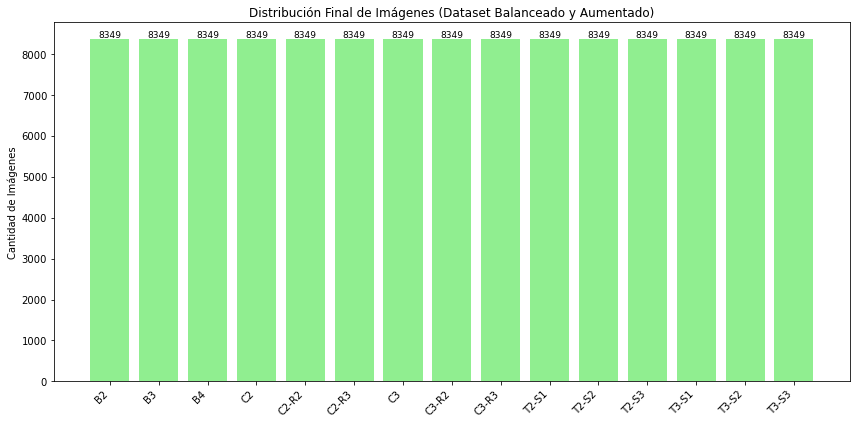

✅ VALIDACIÓN EXITOSA: Las imágenes verificadas cumplen estrictamente con la resolución de 640x640 píxeles.
✅ El dataset está listo para ser utilizado en el entrenamiento del modelo YOLO.


In [35]:
def validate_output(output_dir):
    if not os.path.exists(output_dir):
        print("El directorio de salida no existe. Asegúrate de haber ejecutado la celda anterior.")
        return
        
    classes = sorted(os.listdir(output_dir))
    new_counts = {}
    all_640 = True
    
    print("Validando dimensiones (640x640) y contando imágenes resultantes...")
    for cls in classes:
        cls_path = os.path.join(output_dir, cls)
        images = glob.glob(os.path.join(cls_path, '*.*'))
        new_counts[cls] = len(images)
        
        # Validar dimensiones en una muestra aleatoria de 5 imágenes por clase para rapidez
        sample_imgs = random.sample(images, min(5, len(images)))
        for img_path in sample_imgs:
            img = cv2.imread(img_path)
            if img is None or img.shape[:2] != (640, 640):
                all_640 = False
                print(f"❌ Error de dimensión detectado en: {img_path} -> {img.shape if img is not None else 'None'}")
                
    # Visualización Final
    plt.figure(figsize=(12, 6))
    bars = plt.bar(new_counts.keys(), new_counts.values(), color='lightgreen')
    plt.xticks(rotation=45, ha='right')
    plt.title('Distribución Final de Imágenes (Dataset Balanceado y Aumentado)')
    plt.ylabel('Cantidad de Imágenes')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=9)
        
    plt.tight_layout()
    plt.show()
    
    if all_640:
        print("✅ VALIDACIÓN EXITOSA: Las imágenes verificadas cumplen estrictamente con la resolución de 640x640 píxeles.")
        print("✅ El dataset está listo para ser utilizado en el entrenamiento del modelo YOLO.")
    else:
        print("⚠️ ADVERTENCIA: Se encontraron imágenes con dimensiones incorrectas.")
        
# Descomenta la siguiente línea para ejecutar la validación
validate_output(output_input.value)